## Cài đặt thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1 Review dữ liệu

### 1.1 Tổng quan dữ liệu

In [6]:
df = pd.read_csv(r"D:\Python\student_depression\data\prediction_model\cleaned_dataset.csv")

Tạo df_student thu hẹp quy mô dữ liệu chứa các học sinh,nghề nghiệp cũng không được khác sinh viên

In [7]:
df_student = df[df['Profession'] == 'Student']

In [8]:
df_student.shape

(27870, 18)

In [9]:
df_student.info()

<class 'pandas.DataFrame'>
Index: 27870 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27870 non-null  int64  
 1   Gender                                 27870 non-null  str    
 2   Age                                    27870 non-null  float64
 3   City                                   27870 non-null  str    
 4   Profession                             27870 non-null  str    
 5   Academic Pressure                      27870 non-null  float64
 6   Work Pressure                          27870 non-null  float64
 7   CGPA                                   27870 non-null  float64
 8   Study Satisfaction                     27870 non-null  float64
 9   Job Satisfaction                       27870 non-null  float64
 10  Sleep Duration                         27870 non-null  str    
 11  Dietary Habits    

In [10]:
df_student.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [11]:
df_student.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [12]:
df_student.shape

(27870, 18)

In [13]:
df_student.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27870.000000,27867.000000,27870.000000
mean,70439.182634,25.821134,3.140617,0.000431,7.656028,2.943559,0.000682,7.157948,3.139520,0.585145
std,40633.159539,4.906574,1.381640,0.044016,1.470835,1.361209,0.044419,3.707180,1.437289,0.492706
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35055.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70654.500000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105813.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


### 1.2 Kiểm tra trùng lặp

In [14]:
df_student.duplicated().sum()
df_student[df_student.duplicated()]

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression


Có thể thấy bộ dữ liệu không có dữ liệu trùng lặp -> Lượt bỏ bước **handle duplicate value**

### 1.3 Kiểm tra missing value

In [15]:
df_student.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

Bộ dữ liệu rất tốt, chỉ có **3** missing value ở **financial_stress**

### 1.4  Kiểm tra giá trị unique

In [16]:
# Xem unique value cho từng cột
for col in df_student.columns:
    print(f"{col}: {df_student[col].unique()}")


id: [     2      8     26 ... 140689 140690 140699]
Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Age: [33. 24. 31. 28. 25. 29. 30. 27. 19. 20. 23. 18. 21. 22. 34. 32. 26. 39.
 35. 42. 36. 58. 49. 38. 51. 44. 43. 46. 59. 54. 48. 56. 37. 41.]
City: <StringArray>
[     'Visakhapatnam',          'Bangalore',           'Srinagar',
           'Varanasi',             'Jaipur',               'Pune',
              'Thane',            'Chennai',             'Nagpur',
             'Nashik',           'Vadodara',             'Kalyan',
             'Rajkot',          'Ahmedabad',            'Kolkata',
             'Mumbai',            'Lucknow',             'Indore',
              'Surat',           'Ludhiana',             'Bhopal',
             'Meerut',               'Agra',          'Ghaziabad',
          'Hyderabad',        'Vasai-Virar',             'Kanpur',
              'Patna',          'Faridabad',              'Delhi',
             'Saanvi',             'M.Tech',       

In [17]:
df['City'].value_counts()

City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna                   2
City                     2
Harsha                   2
M.Tech                   1
Less Delhi               1
3.0                    

Các cột không hợp lệ hoặc chỉ xuất hiện rất ít sẽ được loại bỏ

### 1.5 Phát hiện ngoại lai

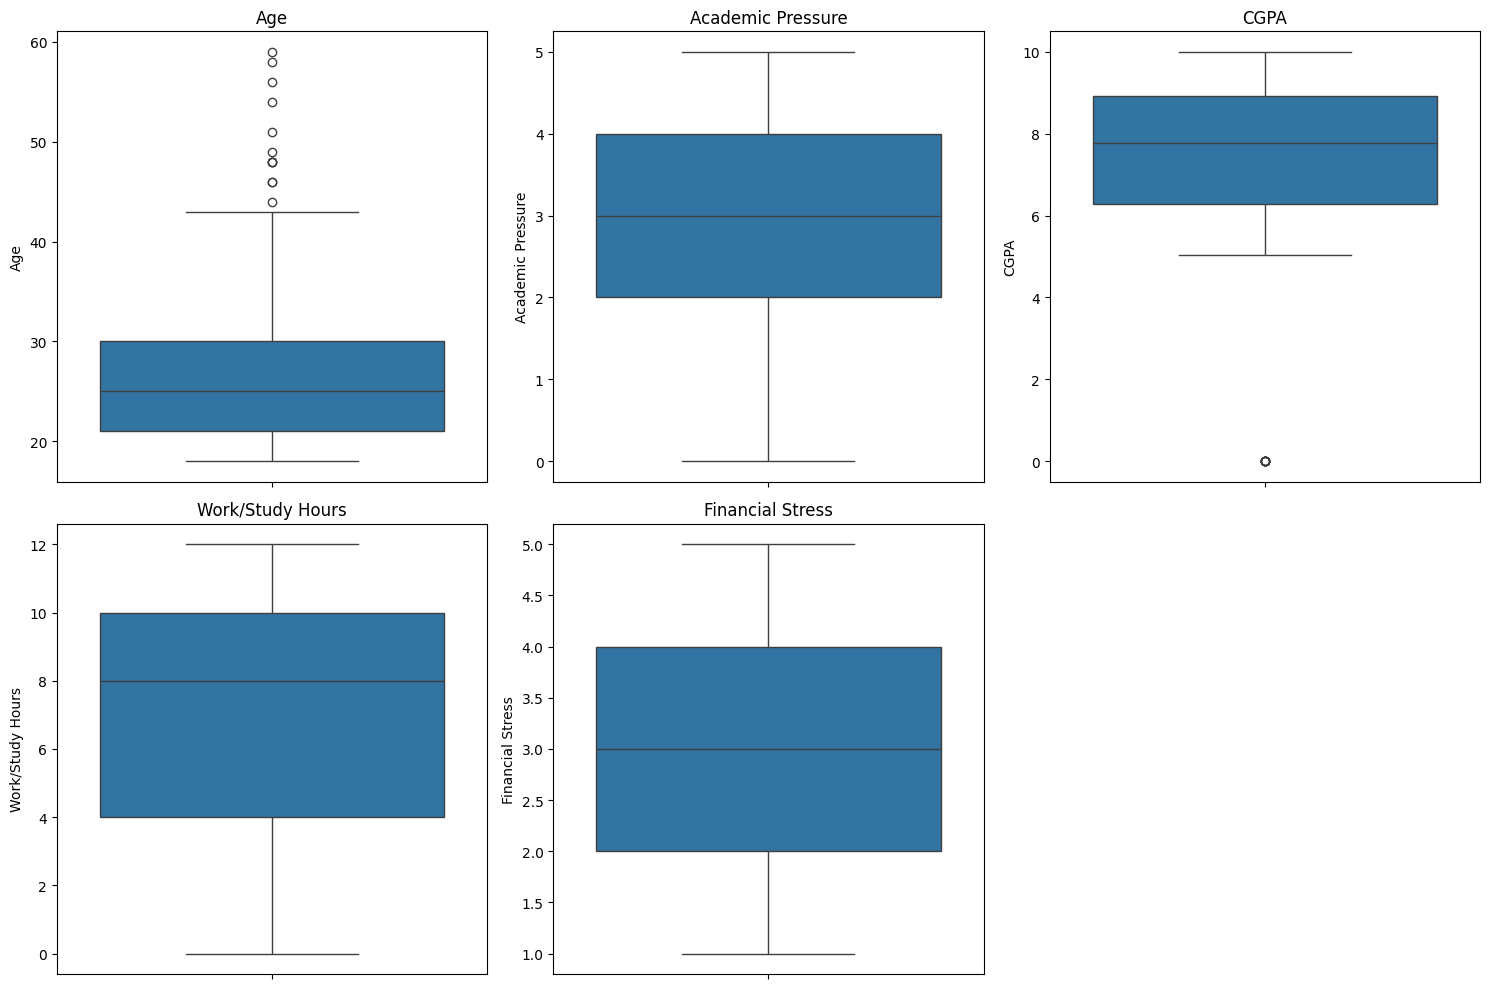

In [18]:
# Vẽ bằng IQR
# List các cột số muốn kiểm tra
numeric_cols = ['Age', 'Academic Pressure', 'CGPA',
                'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)  # Tùy số cột, chỉnh 2 hàng 4 cột
    sns.boxplot(y=df_student[col])
    plt.title(col)
plt.tight_layout()
plt.show()

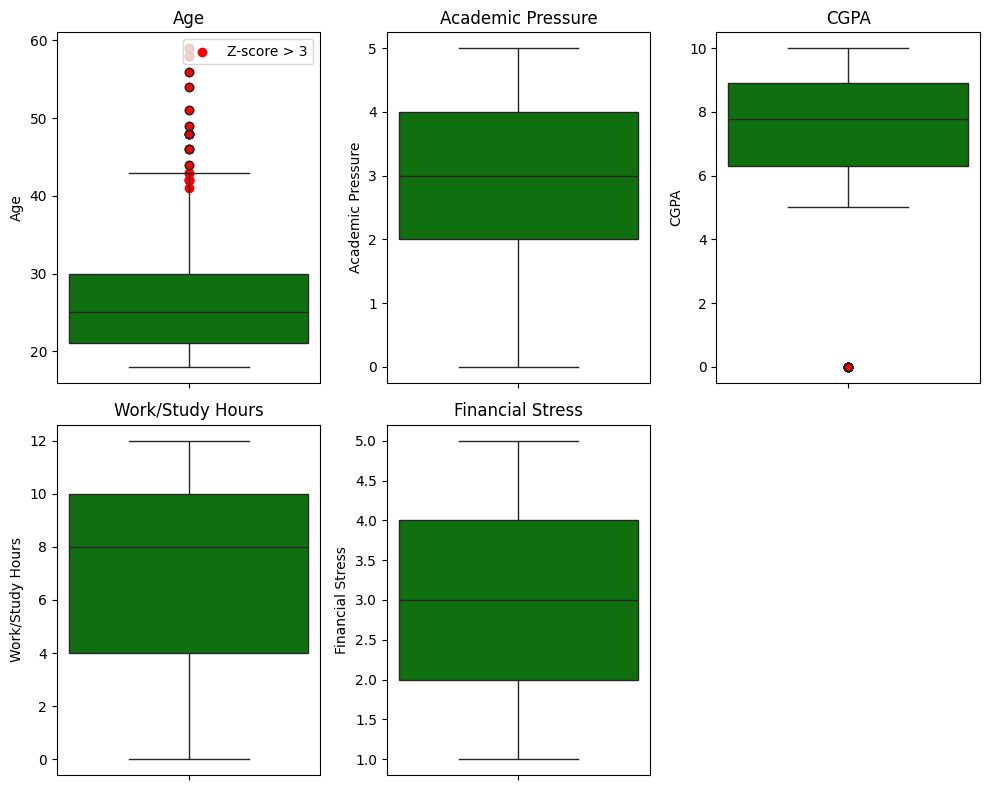

In [19]:
#Vẽ bằng Z-score
# Các cột số
numeric_cols = ['Age', 'Academic Pressure', 'CGPA',
                'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(10, 8))
for i, col in enumerate(numeric_cols):
    # Tính z-score
    z = (df_student[col] - df_student[col].mean()) / df_student[col].std()
    # Đánh dấu outlier
    outlier = np.abs(z) > 3
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_student[col], color="green")
    plt.scatter(np.zeros_like(df_student[col][outlier]), df_student[col][outlier], color='red', label='Z-score > 3')
    plt.title(col)
    if i == 0:
        plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 2 Data Cleaning

### 2.1 Chuẩn hóa tên cột

In [20]:
# Chuẩn hóa tên cột
def clean_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("?", "")
        .str.lower()
    )
    return df

In [21]:
df_cleaned = clean_column_names(df_student)

In [22]:
# đổi tên cột
df_cleaned = df_cleaned.rename(columns={'have_you_ever_had_suicidal_thoughts_': 'suicidal_thoughts', 'family_history_of_mental_illness': 'family_mental_history'})

In [23]:
df_cleaned.columns

Index(['id', 'gender', 'age', 'city', 'profession', 'academic_pressure',
       'work_pressure', 'cgpa', 'study_satisfaction', 'job_satisfaction',
       'sleep_duration', 'dietary_habits', 'degree', 'suicidal_thoughts',
       'work/study_hours', 'financial_stress', 'family_mental_history',
       'depression'],
      dtype='str')

### 2.2 Xử lý dữ liệu thiếu và dữ liệu không hợp lệ

In [24]:
# Những giá trị của 'financial_stress' là ? sẽ được thay thành nan
df_cleaned['financial_stress'] = df_cleaned['financial_stress'].replace('?', np.nan)

# Thay giá trị thiếu bằng median
df_cleaned['financial_stress'] = df_cleaned['financial_stress'].fillna(df_cleaned['financial_stress'].median())

In [25]:
# Chuyển yes/no về 1/0
df_cleaned['suicidal_thoughts'] = df_cleaned['suicidal_thoughts'].map({'No': 0, 'Yes': 1})
df_cleaned['family_mental_history'] = df_cleaned['family_mental_history'].map({'No': 0, 'Yes': 1})

In [26]:
# Loại bỏ toàn bộ các bản ghi có CGPA = 0.
df_cleaned = df_cleaned[df_cleaned['cgpa'] != 0]

# Làm tròn CGPA về 2 chữ số thập phân
df_cleaned['cgpa'] = df_cleaned['cgpa'].round(2)

In [27]:
for col in df_cleaned.columns:
  print(f"{col}: {df_cleaned[col].unique()}")

id: [     2      8     26 ... 140689 140690 140699]
gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
age: [33. 24. 31. 28. 25. 29. 30. 27. 19. 20. 23. 18. 21. 22. 34. 32. 26. 39.
 35. 42. 36. 58. 49. 51. 44. 38. 43. 46. 59. 54. 48. 56. 37. 41.]
city: <StringArray>
[     'Visakhapatnam',          'Bangalore',           'Srinagar',
           'Varanasi',             'Jaipur',               'Pune',
              'Thane',            'Chennai',             'Nagpur',
             'Nashik',           'Vadodara',             'Kalyan',
             'Rajkot',          'Ahmedabad',            'Kolkata',
             'Mumbai',            'Lucknow',             'Indore',
              'Surat',           'Ludhiana',             'Bhopal',
             'Meerut',               'Agra',          'Ghaziabad',
          'Hyderabad',        'Vasai-Virar',             'Kanpur',
              'Patna',          'Faridabad',              'Delhi',
             'Saanvi',             'M.Tech',       

**Lưu ý**
Sau khi loại bỏ các bản ghi có CGPA=0, biến work_pressure không còn đa dạng giá trị (chỉ còn giá trị duy nhất 0). Do đó, biến này đã bị loại khỏi tập dữ liệu để tránh ảnh hưởng đến chất lượng phân tích.

### 2.3 Loại bỏ các cột không cần thiết

In [28]:
# Loại bỏ cột Profession vì chỉ còn mỗi giá trị 'Student'
df_cleaned = df_cleaned.drop(columns=['profession', 'id'])

In [29]:
# Loại bỏ cột 'work_pressure'
df_cleaned = df_cleaned.drop(columns=['work_pressure'])

In [30]:
df_cleaned.drop(columns=['city'], inplace=True)

In [31]:
# Xem các giá trị cột job_satisfaction
df_cleaned['job_satisfaction'].value_counts()

job_satisfaction
0.0    27859
3.0        1
2.0        1
Name: count, dtype: int64

- Ta cũng nhận thấy cột job_satisfaction chỉ có một giá trị 3 và 1 giá trị 2 nên ta cũng sẽ bỏ cột này

In [32]:
df_cleaned = df_cleaned.drop(columns='job_satisfaction')

In [33]:
df_cleaned['depression'].value_counts()

depression
1    16304
0    11557
Name: count, dtype: int64

In [34]:
df_cleaned.head()

,gender,age,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work/study_hours,financial_stress,family_mental_history,depression
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,1,3.0,1.0,0,1
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,0,3.0,2.0,1,0
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,0,9.0,1.0,1,0
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,1,4.0,5.0,1,1
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,1,1.0,1.0,0,0


## 4 Data Transformation

### 4.1 Encoding biến phân loại

In [35]:
# Sao chép DataFrame đã làm sạch từ bước trước để giữ nguyên dữ liệu gốc
df_transformed = df_cleaned.copy()

In [36]:
# Label Encoding nhị phân
df_transformed['gender'] = df_cleaned['gender'].map({'Male':0, 'Female':1})
df_transformed['suicidal_thoughts'] = df_cleaned['suicidal_thoughts']
df_transformed['family_mental_history'] = df_cleaned['family_mental_history']

In [37]:
# Map giá trị sleep_duration thành số có thứ tự
sleep_map = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4,
    'Others': 0
}
df_transformed['sleep_duration'] = df_transformed['sleep_duration'].map(sleep_map)

Thời gian ngủ có thứ tự rõ rệt (ngủ nhiều hơn → giá trị cao hơn).

Mô hình hiểu rằng ngủ 7–8 giờ > ngủ 5–6 giờ.


In [38]:
# Map dietary_habits thành số thứ tự
diet_map = {
    'Unhealthy': 1,
    'Moderate': 2,
    'Healthy': 3,
    'Others': 0
}
df_transformed['dietary_habits'] = df_transformed['dietary_habits'].map(diet_map)


In [39]:
print(df_transformed.columns)


Index(['gender', 'age', 'academic_pressure', 'cgpa', 'study_satisfaction',
       'sleep_duration', 'dietary_habits', 'degree', 'suicidal_thoughts',
       'work/study_hours', 'financial_stress', 'family_mental_history',
       'depression'],
      dtype='str')


Mức độ "Healthy" > "Moderate" > "Unhealthy".



In [40]:
# One-Hot Encoding Degree
degree_dummies = pd.get_dummies(df_transformed['degree'], prefix='degree', drop_first=True)

# Nối các cột mới
df_transformed = pd.concat([df_transformed, degree_dummies], axis=1)

# Bỏ cột gốc
df_transformed.drop(['degree'], axis=1, inplace=True)


In [41]:
print(df_transformed.columns)


Index(['gender', 'age', 'academic_pressure', 'cgpa', 'study_satisfaction',
       'sleep_duration', 'dietary_habits', 'suicidal_thoughts',
       'work/study_hours', 'financial_stress', 'family_mental_history',
       'depression', 'degree_B.Com', 'degree_B.Ed', 'degree_B.Pharm',
       'degree_B.Tech', 'degree_BA', 'degree_BBA', 'degree_BCA', 'degree_BE',
       'degree_BHM', 'degree_BSc', 'degree_Class 12', 'degree_LLB',
       'degree_LLM', 'degree_M.Com', 'degree_M.Ed', 'degree_M.Pharm',
       'degree_M.Tech', 'degree_MA', 'degree_MBA', 'degree_MBBS', 'degree_MCA',
       'degree_MD', 'degree_ME', 'degree_MHM', 'degree_MSc', 'degree_Others',
       'degree_PhD'],
      dtype='str')


### 4.2 Scaling các biến số liên tục

Chuẩn hóa thành phân phối chuẩn (mean=0, std=1).


In [42]:
from sklearn.preprocessing import StandardScaler

# Danh sách cột
cols_to_scale = [
    'age', 'cgpa', 'academic_pressure',
    'study_satisfaction',
    'work/study_hours', 'financial_stress'
]

# Khởi tạo scaler
scaler = StandardScaler()

# Fit-transform
df_transformed[cols_to_scale] = scaler.fit_transform(df_transformed[cols_to_scale])

### 4.3 Tạo đặc trưng mới

Nhóm thời lượng ngủ >=7 giờ thành Adequate=1, còn lại=0.


In [43]:
# Nhóm >=7 giờ thành Adequate=1, còn lại=0
df_transformed['sleep_adequate'] = df_transformed['sleep_duration'].apply(lambda x: 1 if x >=3 else 0)

In [44]:
# Vì đã chuẩn hóa, median=0
df_transformed['high_academic_pressure'] = df_transformed['academic_pressure'].apply(lambda x: 1 if x > 0 else 0)

Học sinh có áp lực cao thường dễ stress và trầm cảm.

In [45]:
df_transformed['stress_interaction'] = df_transformed['financial_stress'] * df_transformed['academic_pressure']

Tương tác giữa tài chính và học tập thường làm tăng nguy cơ trầm cảm.


### 4.4 Kiểm tra kết quả cuối cùng

In [46]:
print("Kích thước cuối cùng:", df_transformed.shape)
print("Số NaN còn lại:", df_transformed.isnull().sum().sum())
df_transformed.describe()




Kích thước cuối cùng: (27861, 42)
Số NaN còn lại: 0


,gender,age,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,suicidal_thoughts,work/study_hours,financial_stress,family_mental_history,depression,sleep_adequate,high_academic_pressure,stress_interaction
count,27861.000000,2.786100e+04,2.786100e+04,2.786100e+04,2.786100e+04,27861.000000,27861.000000,27861.000000,2.786100e+04,2.786100e+04,27861.000000,27861.000000,27861.000000,27861.000000,27861.000000
mean,0.442841,5.024117e-17,-1.851527e-16,4.529356e-16,-1.468980e-16,2.397294,1.903342,0.632605,7.523424e-18,1.224150e-17,0.483938,0.585191,0.479846,0.410430,0.152073
std,0.496731,1.000018e+00,1.000018e+00,1.000018e+00,1.000018e+00,1.127916,0.797760,0.482104,1.000018e+00,1.000018e+00,0.499751,0.492698,0.499603,0.491921,0.985227
min,0.000000,-1.594302e+00,-2.274721e+00,-1.794696e+00,-2.163993e+00,0.000000,0.000000,0.000000,-1.930955e+00,-1.488479e+00,0.000000,0.000000,0.000000,0.000000,-2.944831
25%,0.000000,-9.827641e-01,-8.264577e-01,-9.343891e-01,-6.939826e-01,1.000000,1.000000,0.000000,-8.518804e-01,-7.927117e-01,0.000000,0.000000,0.000000,0.000000,-0.132470
50%,0.000000,-1.673803e-01,-1.023261e-01,7.612978e-02,4.102269e-02,2.000000,2.000000,1.000000,2.271939e-01,-9.694442e-02,0.000000,1.000000,0.000000,0.000000,0.080120
75%,1.000000,8.518494e-01,6.218056e-01,8.613303e-01,7.760280e-01,3.000000,3.000000,1.000000,7.667311e-01,5.988228e-01,1.000000,1.000000,1.000000,1.000000,0.804983
max,1.000000,6.763382e+00,1.345937e+00,1.598736e+00,1.511033e+00,4.000000,3.000000,1.000000,1.306268e+00,1.294590e+00,1.000000,1.000000,1.000000,1.000000,3.385874


In [47]:
# Tính tổng số NaN trên từng cột
nan_counts = df_transformed.isnull().sum()

# Chỉ chọn những cột có ít nhất 1 giá trị NaN
nan_counts = nan_counts[nan_counts > 0]

# In ra danh sách cột và số lượng NaN của từng cột
print(nan_counts)

Series([], dtype: int64)


In [48]:
print("NaN còn lại:", df_transformed.isnull().sum().sum())
df_transformed.head(5)

NaN còn lại: 0


,gender,age,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,suicidal_thoughts,work/study_hours,financial_stress,...,degree_MCA,degree_MD,degree_ME,degree_MHM,degree_MSc,degree_Others,degree_PhD,sleep_adequate,high_academic_pressure,stress_interaction
0,0,1.463387,1.345937,0.895469,-0.693983,2,3,1,-1.121649,-1.488479,...,False,False,False,False,False,False,False,0,1,-2.003399
1,1,-0.371226,-0.826458,-1.200674,1.511033,2,2,0,-1.121649,-0.792712,...,False,False,False,False,False,False,False,0,0,0.655143
2,0,1.055695,-0.102326,-0.429130,1.511033,1,3,0,0.496962,-1.488479,...,False,False,False,False,False,False,False,0,0,0.152310
3,1,0.444157,-0.102326,-1.412337,-0.693983,3,2,1,-0.851880,1.294590,...,False,False,False,False,False,False,False,1,0,-0.132470
4,1,-0.167380,0.621806,0.321932,0.041023,2,2,1,-1.661186,-1.488479,...,False,False,False,False,False,False,False,0,1,-0.925545


## 5 Modeling – Huấn luyện mô hình dự đoán

## 5.1 Data Splitting

In [49]:
# Bỏ cột target ra khỏi feature
X = df_transformed.drop(['depression'], axis=1)

# Lấy cột target
y = df_transformed['depression']


In [50]:
print(y.value_counts(normalize=True))


depression
1    0.585191
0    0.414809
Name: proportion, dtype: float64


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 20% dữ liệu cho test
    random_state=42,        # Đảm bảo kết quả tái lập
    stratify=y              # Giữ tỷ lệ nhãn giống nhau
)

In [52]:
import joblib
joblib.dump(scaler, "D:\\Python\\student_depression\\model\\predict\\scaler.pkl")


['D:\\Python\\student_depression\\model\\predict\\scaler.pkl']



##
5.2 Modeling – Huấn luyện mô hình dự đoán có giám sát

### 5.2.1 Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

# Khởi tạo mô hình Logistic Regression
# class_weight='balanced' giúp điều chỉnh trọng số nhãn (trong trường hợp nhãn hơi lệch)
logreg = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)

# Huấn luyện mô hình trên tập train
logreg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Dự đoán trên tập test



In [54]:
# Dự đoán nhãn
y_pred_logreg = logreg.predict(X_test)

# Dự đoán xác suất
y_proba_logreg = logreg.predict_proba(X_test)[:,1]


In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

# Classification report (precision, recall, F1)
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba_logreg)
print("ROC-AUC Score:", roc_auc)


Accuracy: 0.8381482146061368
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81      2312
           1       0.87      0.85      0.86      3261

    accuracy                           0.84      5573
   macro avg       0.83      0.84      0.83      5573
weighted avg       0.84      0.84      0.84      5573

Confusion Matrix:
 [[1910  402]
 [ 500 2761]]
ROC-AUC Score: 0.917030752449256


In [57]:
# Hiển thị trọng số từng biến
feature_importance = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
print(feature_importance)


suicidal_thoughts         2.628679e+00
academic_pressure         1.129732e+00
financial_stress          7.956044e-01
age                      -5.769616e-01
dietary_habits           -5.710488e-01
work/study_hours          4.294462e-01
study_satisfaction       -3.453618e-01
sleep_duration           -2.350719e-01
family_mental_history     2.314713e-01
sleep_adequate            1.382601e-01
degree_Class 12          -1.070131e-01
degree_BHM               -8.831554e-02
degree_BSc                8.787363e-02
cgpa                      8.628160e-02
degree_B.Tech             8.587856e-02
degree_LLM                8.508982e-02
degree_MCA                7.018761e-02
degree_BA                -5.361643e-02
degree_MBBS               5.283626e-02
degree_MSc               -5.241875e-02
degree_M.Com             -4.729303e-02
degree_M.Tech            -4.687444e-02
degree_BBA                4.102446e-02
degree_LLB                3.911644e-02
degree_MBA               -3.539801e-02
degree_B.Pharm           

### 5.2.3 XGBoost

In [59]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(max_depth=10, n_estimators=200, learning_rate=0.05)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [60]:
xgb_y_pred = xgb_model.predict(X_test)

In [61]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report (XGBoost):")
print(classification_report(y_test, xgb_y_pred))
cm = confusion_matrix(y_test, xgb_y_pred)
print("Confusion matrix:\n", cm)

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.80      0.77      0.79      2312
           1       0.84      0.86      0.85      3261

    accuracy                           0.83      5573
   macro avg       0.82      0.82      0.82      5573
weighted avg       0.83      0.83      0.83      5573

Confusion matrix:
 [[1785  527]
 [ 441 2820]]


### Export model

In [56]:
import joblib
joblib.dump(logreg, "D:\\Python\\student_depression\\model\\predict\\logreg.pkl")


['D:\\Python\\student_depression\\model\\predict\\logreg.pkl']